# **NYC Taxi Fare Prediction**
Build a Feed-Forward Neural Network that predicts the fare amount for cab rides in New York City using spatial (GPS) and time-based data.

The Data: We are using the NYC Taxi Fares dataset. The target variable is fare_amount. You will use coordinates, passenger counts, and derived time features to make predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset 

In [2]:
df = pd.read_csv('NYCTaxiFares.csv')
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2010-04-19 08:17:56 UTC,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1
1,2010-04-17 15:43:53 UTC,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1
2,2010-04-17 11:23:26 UTC,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2
3,2010-04-11 21:25:03 UTC,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1
4,2010-04-17 02:19:01 UTC,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1


## **Exploratory Data Analysis (EDA)**

Perform some exploratory data analysis on the dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   pickup_datetime    120000 non-null  object 
 1   fare_amount        120000 non-null  float64
 2   fare_class         120000 non-null  int64  
 3   pickup_longitude   120000 non-null  float64
 4   pickup_latitude    120000 non-null  float64
 5   dropoff_longitude  120000 non-null  float64
 6   dropoff_latitude   120000 non-null  float64
 7   passenger_count    120000 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 7.3+ MB


In [4]:
df.isnull().sum()

pickup_datetime      0
fare_amount          0
fare_class           0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [5]:
df.isna().sum()

pickup_datetime      0
fare_amount          0
fare_class           0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

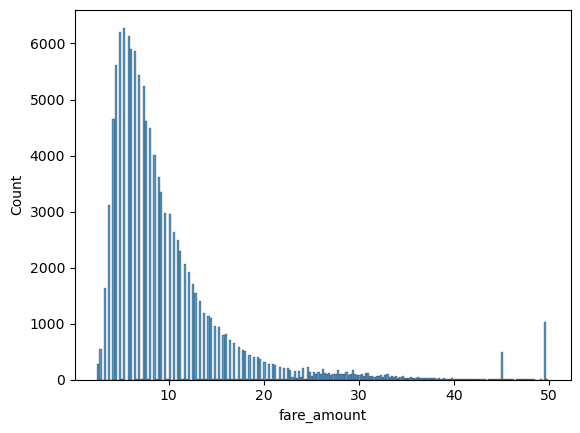

In [6]:
sns.histplot(data = df['fare_amount'])
plt.show()

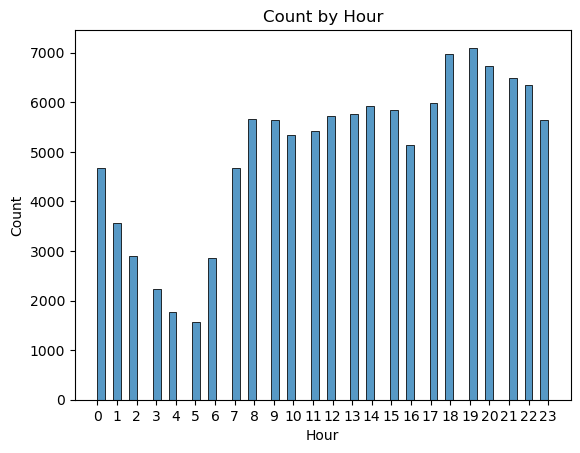

In [7]:
hour = pd.to_datetime(df['pickup_datetime']).dt.hour 
sns.histplot(data = hour)
plt.xticks(hour.unique())
plt.xlabel('Hour')
plt.title('Count by Hour')
plt.show()

<AxesSubplot:>

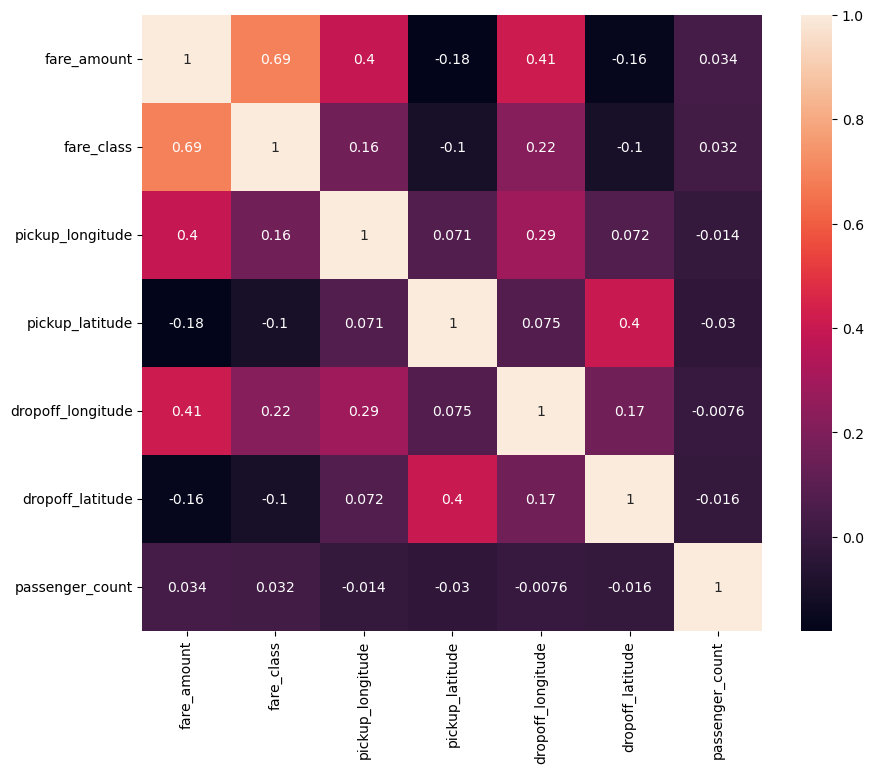

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, ax=ax)

## **Feature Engineering**

In this section, we convert raw data (GPS coordinates and timestamps) into meaningful numerical values that a Neural Network can process. We will calculate the physical distance of the ride and create simple binary flags for the time of day and the type of day.



### Define the Euclidean Distance Function

 Instead of using complex trigonometry, we apply the Pythagorean theorem to calculate the straight-line distance between coordinates.
 1. Define the function euclidean_distance.
 2. Calculate the difference between latitudes and the difference between longitudes.
 3. Square both differences, add them together, and take the square root ($\sqrt{a^2 + b^2}$).

In [9]:
def euclidean_distance(df, lat1, long1, lat2, long2):
    
    # Calculate the straight-line distance using the Pythagorean theorem
    lat_diff = df[lat1]-df[lat2]
    long_diff = df[long1]-df[long2]

    dist = np.sqrt(lat_diff**2 + long_diff**2)
    
    return dist

### Create Spatial and Time-Based Features
Now we apply the simple distance function and handle the timestamp data.

1. **Calculate Distance:** Create a new column dist using your euclidean_distance function.

2. **Adjust Timezone:** Convert the pickup_datetime column to a pandas datetime object and subtract 4 hours to match NYC local time (EDT).

3. **Create is_AM Flag:** Create a feature that is 1 if the ride occurred in the morning (before 12 PM) and 0 otherwise.

4. **Create is_weekday Flag:** Create a feature that is 1 if the ride occurred on a weekday (Monday-Friday) and 0 if it was on a weekend.

In [10]:
def add_spatial_time_features(df, p_lat, p_long, d_lat, d_long, p_time, isEDT=False):
    # 1. Create the Spatial Feature using Euclidean Distance
    df['dist'] = euclidean_distance(df, p_lat, p_long, d_lat, d_long)

    # 2. Extract and Adjust Time (UTC to EDT)
    df[p_time] = pd.to_datetime(df[p_time])
    if not isEDT: 
        df[p_time] =  df[p_time] - pd.Timedelta(hours=4)

    # 3. Create Binary Numerical Features (Not Categorical)
    # Morning (AM) is 1, Afternoon/Evening (PM) is 0
    df['is_AM'] =  (df[p_time].dt.hour < 12).astype(int)

    # Weekday (Mon-Fri) is 1, Weekend (Sat-Sun) is 0
    df['is_weekday'] = (df[p_time].dt.weekday <= 5).astype(int)

    return df

In [11]:
df = add_spatial_time_features(df, 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'pickup_datetime')

### Define Features (X) and Target Label (y)
Finally, we organize our processed features into a matrix for the model to use.

- **Select Features:** Choose the coordinates, passenger count, our new dist feature, and the binary time flags.

- **Define X:** Convert the feature columns into a NumPy array.

- **Define y:** Assign the fare_amount column as the target variable.

In [12]:
X = df.drop(['pickup_datetime', 'fare_amount', 'fare_class'], axis=1)
X.columns

Index(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'dist', 'is_AM', 'is_weekday'],
      dtype='object')

In [13]:
y = df['fare_amount'] 

In [14]:
# Create input (X) and target (y) arrays
X = X.values
y = y.values

## **Data Splitting & Scaling**

-  Split X and y into a temporary set (85%) and a Test set (15%)
-  Split the temporary set into Train (82%) and Validation (18%)
- Initialize the StandardScaler and scale your 3 datasets properly.

In [15]:
# First split: split X and y into a temporary set (85%) and a Test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.15 , random_state = 42)

In [16]:
# Split the temporary set into Train (82%) and Validation (18%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.18 , random_state = 42)

In [17]:
print(f"Train set size: {X_train.shape[0]} | Validation set size: {X_val.shape[0]} | Test set size: {X_test.shape[0]}")

Train set size: 83640 | Validation set size: 18360 | Test set size: 18000


In [18]:
# Initialize the StandardScaler and scale the 3 datasets properly.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [19]:
# save scaler to file 
joblib.dump(scaler, 'NYCTaxiScaler.bin')

['NYCTaxiScaler.bin']

## **Tensors and DataLoaders**




In [20]:
# Convert to PyTorch Tensors
train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).unsqueeze(1))
val_ds = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val).unsqueeze(1))

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_ds, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_ds, batch_size = batch_size, shuffle = False)

## **Build the Model**

In [21]:
class NYCTaxiModel(nn.Module):
    def __init__(self, ):
        super().__init__()

        #layer 1
        self.layer1 = nn.Linear(8, 128)
        self.bn1 = nn.BatchNorm1d(128)

        #layer 2
        self.layer2 = nn.Linear(128, 64)

        self.output_layer = nn.Linear(64, 1) 
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # layer 1
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        # layer 2 
        x = self.layer2(x)
        x = self.relu(x)

        x = self.output_layer(x)
        
        return x

model = NYCTaxiModel()
model

NYCTaxiModel(
  (layer1): Linear(in_features=8, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)

In [22]:
# Define the Loss Function for Regression (MSE)
criterion = nn.MSELoss()

# Define the Optimizer (Adam) with a learning rate of 0.001
optimizer = optim.Adam(model.parameters(), lr = 0.001)

## **The Training Loop**

In [23]:
epochs = 200
train_losses, val_losses = [], []

for epoch in range(epochs):
    # ---TRAINING ---
    model.train()
    epoch_train_loss = 0

    for batch_X, batch_y in train_loader:
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- VALIDATION ---
    model.eval()
    epoch_val_loss = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            val_loss = criterion(predictions, batch_y)
            epoch_val_loss += val_loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}')

Epoch [10/200] | Train Loss: 10.79516 | Val Loss: 9.41994
Epoch [20/200] | Train Loss: 10.44137 | Val Loss: 9.30689
Epoch [30/200] | Train Loss: 10.20641 | Val Loss: 9.16482
Epoch [40/200] | Train Loss: 10.09892 | Val Loss: 9.43095
Epoch [50/200] | Train Loss: 10.03767 | Val Loss: 9.11429
Epoch [60/200] | Train Loss: 9.88364 | Val Loss: 9.07971
Epoch [70/200] | Train Loss: 9.79874 | Val Loss: 9.02662
Epoch [80/200] | Train Loss: 9.77821 | Val Loss: 9.04693
Epoch [90/200] | Train Loss: 9.65985 | Val Loss: 9.01867
Epoch [100/200] | Train Loss: 9.58908 | Val Loss: 8.94983
Epoch [110/200] | Train Loss: 9.55945 | Val Loss: 8.90097
Epoch [120/200] | Train Loss: 9.58648 | Val Loss: 8.87492
Epoch [130/200] | Train Loss: 9.45353 | Val Loss: 8.87778
Epoch [140/200] | Train Loss: 9.45960 | Val Loss: 8.86283
Epoch [150/200] | Train Loss: 9.42903 | Val Loss: 8.97151
Epoch [160/200] | Train Loss: 9.44110 | Val Loss: 8.94543
Epoch [170/200] | Train Loss: 9.36880 | Val Loss: 8.88750
Epoch [180/200] | 

## **Plot The Loss Curve**

- Use matplotlib to plot train_losses and val_losses

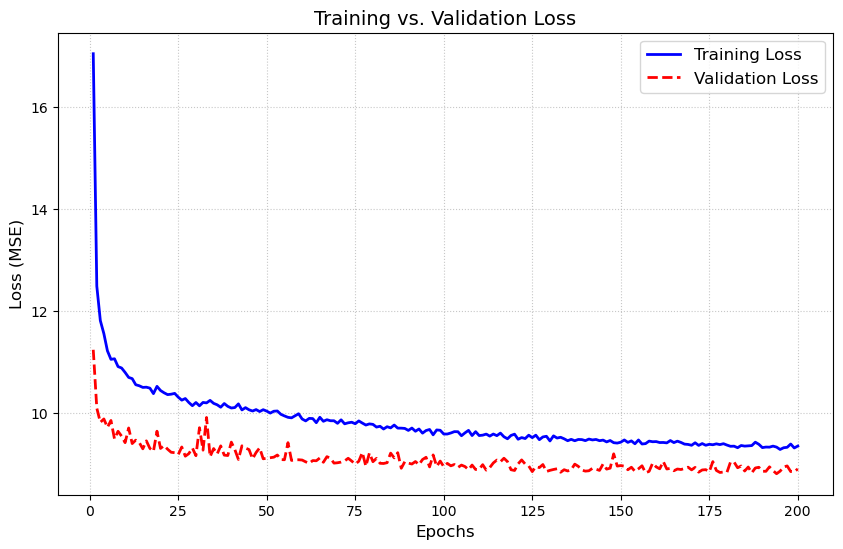

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--')

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training vs. Validation Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## **Final Testset Evaluation**

In [25]:
model.eval()

with torch.no_grad():
    # Get predictions for the entire test set
    test_predictions = model(X_test_tensor)

    # Calculate test loss
    test_loss = criterion(test_predictions, y_test_tensor)
    print(f'Final Test Loss (MSE): {test_loss.item():.5f}')

    # Calculate RMSE (Root Mean Squared Error) to see average error in dollars
    rmse = torch.sqrt(test_loss)
    print(f'Final Test RMSE: ${rmse.item():.2f}')

    # Calculate R2 for Test Set
    r2_test = r2_score(y_test_tensor, test_predictions)
    print(f"R2 Score (Test Set): {r2_test:.5f}")

Final Test Loss (MSE): 8.53738
Final Test RMSE: $2.92
R2 Score (Test Set): 0.84295


## **Saving the Trained Model**

In [26]:
# Save the model's weights and biases to a file
torch.save(model.state_dict(), 'NYCTaxiModel.pt')

## **Loading the Saved Model**

In [27]:
# 1. Re-instantiate the model with the same input features
saved_model = NYCTaxiModel()

# 2. Load the saved state dictionary
state_dict = torch.load('NYCTaxiModel.pt')
saved_model.load_state_dict(state_dict)

# 3. Set to evaluation mode (This is CRITICAL for BatchNorm and Dropout layers)
saved_model.eval()

NYCTaxiModel(
  (layer1): Linear(in_features=8, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)

In [28]:
#load scaler 
NYCTaxiScaler = joblib.load('NYCTaxiScaler.bin') 

## **Prediction on New Data**

Use the loaded_model to make predictions on new unseen data.

<table style="display: inline-block">
<tr><th>Column</th><th>Value</th></tr>
<tr><td>pickup_latitude</td><td>40.7306</td></tr>
<tr><td>pickup_longitude</td><td>-73.9352</td></tr>
<tr><td>dropoff_latitude</td><td>40.7447</td></tr>
<tr><td>dropoff_longitude</td><td>-73.9754</td></tr>
<tr><td>passenger_count</td><td>1</td></tr>
<tr><td>EDTdate</td><td>2010-04-15 08:30:00</td></tr>

In [29]:
nd_dict = {
    'pickup_longitude': -73.9352, 
    'pickup_latitude': 40.7306, 
    'dropoff_longitude': -73.9754, 
    'dropoff_latitude': 40.7447,
    'passenger_count': 1, 
    'EDTdate': '2010-04-15 08:30:00'
}

# convert to dataframe 
nd_df = pd.DataFrame(nd_dict, index=[0])

# add and remove features 
nd_df = add_spatial_time_features(nd_df, 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'EDTdate', True)
nd_df = nd_df.drop(['EDTdate'], axis = 1)

In [30]:
# transform with scaler 
nd_df = NYCTaxiScaler.transform(nd_df.values)  

# convert to tensor 
nd_tensor = torch.FloatTensor(nd_df)

# Get predictions for the test data
with torch.no_grad():
    new_data_prediction = saved_model(nd_tensor) 

print(f"The predicted fare is: {new_data_prediction.item():.2f}") 

The predicted fare is: 11.55
